# Clasificacion especies Marinas

**Autor:** _(Sharon, Marco Fabian, Johel)_

**Curso:** _(Inteligencia Artificial)_

**Fecha:** _(13-07-2026)_

Este notebook documenta un proyecto de **clasificación de imágenes** que identifica
especies de peces a partir de fotografías, utilizando **Transfer Learning** con el
modelo preentrenado **MobileNetV2** (entrenado originalmente sobre el dataset ImageNet,
con ~14 millones de imágenes).

El flujo de trabajo se divide en las siguientes etapas:

1. **Configuración inicial** — parámetros globales del proyecto (rutas, tamaño de imagen, batch size, épocas, semilla).
2. **Reorganización del dataset** — se toman las imágenes crudas descargadas de Kaggle y se dividen en carpetas `train` / `validation` / `test`.
3. **Generadores de datos** — se crean los `ImageDataGenerator` de Keras, que leen las imágenes desde disco, las normalizan y aplican *data augmentation* (rotaciones, zoom, volteos, etc.) para el set de entrenamiento.
4. **Construcción del modelo** — se arma una red neuronal convolucional (CNN) usando MobileNetV2 como extractor de características, agregando una "cabeza" de clasificación propia.
5. **Entrenamiento en dos fases**:
   - **Fase 1:** se entrena solo la cabeza del modelo, manteniendo congelada la base de MobileNetV2.
   - **Fase 2 (Fine-tuning):** se descongelan las últimas 30 capas de MobileNetV2 y se reentrena con una tasa de aprendizaje mucho más baja, para ajustar el modelo a las características específicas de los peces.
6. **Evaluación** — se mide el desempeño del modelo sobre el set de prueba (accuracy, loss, reporte de clasificación y matriz de confusión).
7. **Guardado del modelo** — se exporta el modelo final entrenado en formato `.keras`.


## 1. Importación de librerías

- `os`, `shutil`, `random`, `pathlib.Path`: manejo de archivos, copiado de imágenes y control de aleatoriedad.
- `numpy`: operaciones numéricas (por ejemplo, obtener la clase con mayor probabilidad).
- `matplotlib.pyplot`: generación de gráficos de precisión y pérdida.
- `tensorflow` / `tensorflow.keras`: construcción, entrenamiento y evaluación de la red neuronal.
- `MobileNetV2`: arquitectura preentrenada que se usa como base del modelo (Transfer Learning).
- `ImageDataGenerator`: carga de imágenes desde disco con *data augmentation* en tiempo real.
- `EarlyStopping`, `ModelCheckpoint`: *callbacks* que evitan el sobreentrenamiento y guardan el mejor modelo.
- `sklearn.metrics`: métricas de evaluación (reporte de clasificación y matriz de confusión).

## 2. Definicion de parametros iniciales

 Parámetro | Descripción                                                                                                               |
|---|---------------------------------------------------------------------------------------------------------------------------|
| `RAW_DATASET_DIR` | Carpeta con el dataset generado por la clase EDA con sus respectivas carpetas por especie                                 |
| `ORGANIZED_DIR` | Carpeta destino donde se creará la estructura `train/validation/test` Tomando en cuenta train="70%",Val="15%",test="15%". |
| `IMG_SIZE` | Tamaño (alto, ancho) al que se redimensionan todas las imágenes: `160x160` px.                                            |
| `BATCH_SIZE` | Cantidad de imágenes que el modelo procesa simultáneamente en cada paso de entrenamiento que sera de 32.                  |
| `EPOCHS` | Número máximo de veces que el modelo recorrerá todo el set de entrenamiento en nuestro caso sera de 20 epocas.            |
| `SEED` | Semilla para hacer reproducibles las divisiones aleatorias del dataset.                                                   |


## 3. Reorganizacion del dataset en train/validation/test
El data set original viene con la siguiente estructura:

Especies encontradas (16):
  - Atun_aleta_amarilla: 30 imágenes
  - Camaron: 50 imágenes
  - Corvina: 50 imágenes
  - Corvina_reina: 27 imágenes
  - Dorada: 27 imágenes
  - Espadín_del_mar_negro: 50 imágenes
  - Jurel: 50 imágenes
  - Marlin_pez_vela: 30 imágenes
  - Parg_rojo: 50 imágenes
  - Pargo_mancha: 186 imágenes
  - Pez_dorado: 40 imágenes
  - Salmonete: 50 imágenes
  - Salmonete_de_fango: 50 imágenes
  - Tiburon_martillo: 40 imágenes
  - Tortuga: 97 imágenes
  - Trucha: 30 imágenes

En dicha reorganizacion se generaran las nuevas carpetas para que luego el modelo pueda realizar el analisis sobre cada una.

Se creara una carpeta llamada: **Dataset organizado** y dentro de ella las carpetas de:**"Train"**,**"Validation"**-**"Test"**


## 4. Generadores de datos (`ImageDataGenerator`)

Para el optimo funcionamiento del modelo se estaran creando 3 generadores:

- **`train_gen`**: aplica *data augmentation* (rotación, desplazamientos, zoom, volteo
  horizontal, etc.) además de normalizar los píxeles al rango `[0, 1]`. Esto ayuda a que
  el modelo generalice mejor y no memorice las imágenes de entrenamiento.
- **`val_gen`**: solo normaliza los píxeles (sin augmentation), ya que se usa para medir
  el desempeño real del modelo durante el entrenamiento.
- **`test_gen`**: igual que `val_gen`, pero con `shuffle=False` para poder comparar
  correctamente las predicciones con las etiquetas verdaderas al evaluar el modelo.

In [ ]:
train_datagen = ImageDataGenerator(
        rescale=1. / 255, #Normaliza los datos de 0-255 a 0-1
        rotation_range=20, #Rota la especie 20 grados
        width_shift_range=0.15, #Desplaza la especie hacia la izquierda
        height_shift_range=0.15, #Desplaza la especie hacia la derecha
        shear_range=0.15, #Aplica una distorsion inclinada a la especie
        zoom_range=0.15, #Acerla la imagen un 15%
        horizontal_flip=True, #Voltea la imagen como un espejo, tomar como referencia que si la imagen inicialmente ve a la izquierdo con este argumento ahora vera a la derecha.
        fill_mode="nearest", #Al rotar la imagen queda algun espacio vacio el fill_mode rellena dichas secuencias en la imagen con los pixeles mas cercanos.
    )

In [ ]:
val_gen = val_test_datagen.flow_from_directory(
        f"{organized_dir}/validation",
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        seed=SEED,
    )

In [ ]:
test_gen = val_test_datagen.flow_from_directory(
        f"{organized_dir}/test",
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False,  # Las imágenes se procesan en orden (alfabético por carpeta/nombre)
    )

## 5. Creacion del modelo

En la creacion del modelo cabe resaltar que se implementaron 2 arquitenturas distintas.

### 5.1 Arquitectura convencional:

- Capa convulucional (3,3)
- BatchNormalization()
- MaxPooling2D(pool_size=(2, 2))
- Conv2D(128, (3, 3)
- GlobalAveragePooling2D()
- Dense(128, activation='relu', kernel_regularizer=l2(0.001))
- ropout(0.5)
- Dense(NUM_CLASSES, activation='softmax')

### Codigo modelo inicial:

    model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

Dicho modelo devolvian los siguientes resultados:

| Clase                  | Precision | Recall | F1-Score | Support |
|------------------------|----------:|--------:|---------:|--------:|
| Atun_aleta_amarilla    | 0.00 | 0.00 | 0.00 | 6 |
| Camaron                | 0.00 | 0.00 | 0.00 | 10 |
| Corvina                | 0.00 | 0.00 | 0.00 | 10 |
| Corvina_reina          | 0.00 | 0.00 | 0.00 | 5 |
| Dorada                 | 0.00 | 0.00 | 0.00 | 5 |
| Espadín_del_mar_negro  | 0.00 | 0.00 | 0.00 | 10 |
| Jurel                  | 0.00 | 0.00 | 0.00 | 10 |
| Marlin_pez_vela        | 0.00 | 0.00 | 0.00 | 6 |
| Parg_rojo              | 0.00 | 0.00 | 0.00 | 10 |
| Pargo_mancha           | 0.22 | 1.00 | 0.36 | 37 |
| Pez_dorado             | 0.00 | 0.00 | 0.00 | 8 |
| Salmonete              | 0.00 | 0.00 | 0.00 | 10 |
| Salmonete_de_fango     | 0.00 | 0.00 | 0.00 | 10 |
| Tiburon_martillo       | 0.00 | 0.00 | 0.00 | 8 |
| Tortuga                | 0.00 | 0.00 | 0.00 | 19 |
| Trucha                 | 0.00 | 0.00 | 0.00 | 6 |
| **Accuracy**           |     - |     - | **0.22** | **170** |
| **Macro Avg**          | **0.01** | **0.06** | **0.02** | **170** |
| **Weighted Avg**       | **0.05** | **0.22** | **0.08** | **170** |


El modelo nos devuelve una precision del 22% y la prediccion por especie estaba por debajo 0.2
Al llegar a dichos resultados nos dimos a la tarea de buscar alguna solucion que nos ayudara a subir la precision del modelo con los datos que teniamos ya que el principal factor se debia a que solo se contaba con **687 imagenes** de **16 especies** y tener un modelo que aprendiera de 0 no iba a ser suficiente por lo que se utilizaria MobileNetV2 para subir la precision de **~60% a 85-95%** con los mismos datos




### 5.1 Arquitectura a partir de un red convolucional preentrenada

La red convolucional preentrenada seria: MobileNetV2 que tiene una base datos de 14 millones de imagenes, dicha red sabe reconocer patrones visuales como:bordes, texturas, formas, sombras lo que hace util para partir en la identificacion de especies marinas.

La arquitectura seria la siguiente:

- Extraccion de caracteristicas

        base_model = MobileNetV2(
        input_shape=img_size + (3,),  #Trabaja con 3 canales RGB, ej: (160, 160, 3)
        include_top=False,            #Extrae características visuales abstractas
        weights="imagenet",           #Carga los pesos preentrenados en ImageNet
    )

        base_model.trainable = False  #fase 1: congelado (Extracción de Características)

- Creacion del modelo secuencial

        model = models.Sequential([
        base_model,  #Extrae características esenciales de cada imagen (congelado)

        layers.GlobalAveragePooling2D(),
        # Compactador: transforma la matriz 3D en un vector plano de 1280 números,
        # donde cada número representa la presencia global de una característica
        # visual (ej. texturas de escamas, formas de aletas).

        layers.Dense(128, activation="relu"),
        # Capa de 128 neuronas completamente conectadas. Combina los 1280 valores
        # anteriores para buscar patrones específicos y exclusivos de los peces.

        layers.Dropout(0.3),
        # Apaga el 30% de las neuronas al azar para evitar que el modelo dependa
        # de ciertas neuronas específicas. Ayuda a evitar el overfitting.

        # Capa de salida: una neurona por especie, con activación softmax
        # (las probabilidades de todas las clases suman 1.0)
        layers.Dense(num_classes, activation="softmax"),
        ])

- Compilación del modelo

        model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # Ajusta pesos y bias
        loss="categorical_crossentropy",  # Función de pérdida: mide el error
        metrics=["accuracy"],             # Métrica de evaluación: mide el acierto
        )

- Ajuste fino al modelo.

        base_model.trainable = True  # Activa las capas que componen MobileNetV2

        # Congelamos todas las capas menos las últimas ~30, que usaremos para
        # aprender a distinguir texturas de escamas, formas de aletas o siluetas
        # específicas de los peces.
        for layer in base_model.layers[:-30]:
        layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Tasa de aprendizaje muy baja
        loss="categorical_crossentropy",
        metrics=["accuracy"],
        )

El ajuste fino consiste en: Descongelar toda la base (`base_model.trainable = True`).
- Se vuelven a congelar todas las capas **excepto las últimas 30**, que son las que
  aprenden los patrones más específicos y de más alto nivel (texturas de escamas,
  formas de aletas, siluetas particulares de cada especie).
- Se recompila el modelo con una tasa de aprendizaje mucho más baja (`1e-5`), 100 veces
  menor que en la fase 1, para hacer ajustes muy sutiles sin "romper" lo ya aprendido
  por MobileNetV2.

-Generacion de graficos
- Evaluacion precision y loss  comparando el train y validacion a lo largo de las epocas.
- Evaluacion del modelo final

        def graficar_historial(history, titulo_sufijo=""):
        # Crea una figura con dos gráficos lado a lado (12x4 pulgadas)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Precisión (Accuracy)
        axes[0].plot(history.history["accuracy"], label="train")
        axes[0].plot(history.history["val_accuracy"], label="val")
        axes[0].set_title(f"Precisión {titulo_sufijo}")
        axes[0].legend()

        # Pérdida (Loss)
        axes[1].plot(history.history["loss"], label="train")
        axes[1].plot(history.history["val_loss"], label="val")
        axes[1].set_title(f"Pérdida {titulo_sufijo}")
        axes[1].legend()

        plt.tight_layout()  # Ajusta márgenes automáticamente
        plt.savefig(f"historial_entrenamiento{titulo_sufijo}.png")  # Guarda el gráfico
        print(f"Gráfico guardado: historial_entrenamiento{titulo_sufijo}.png")



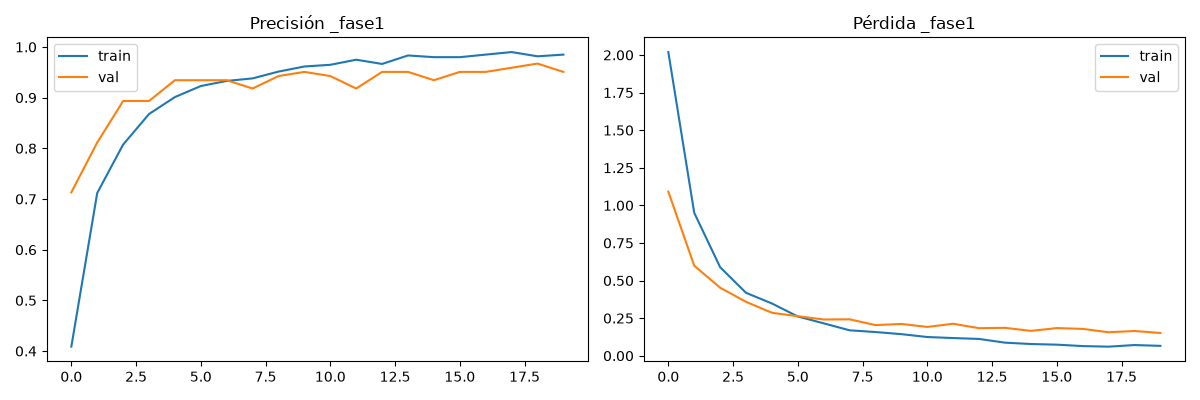

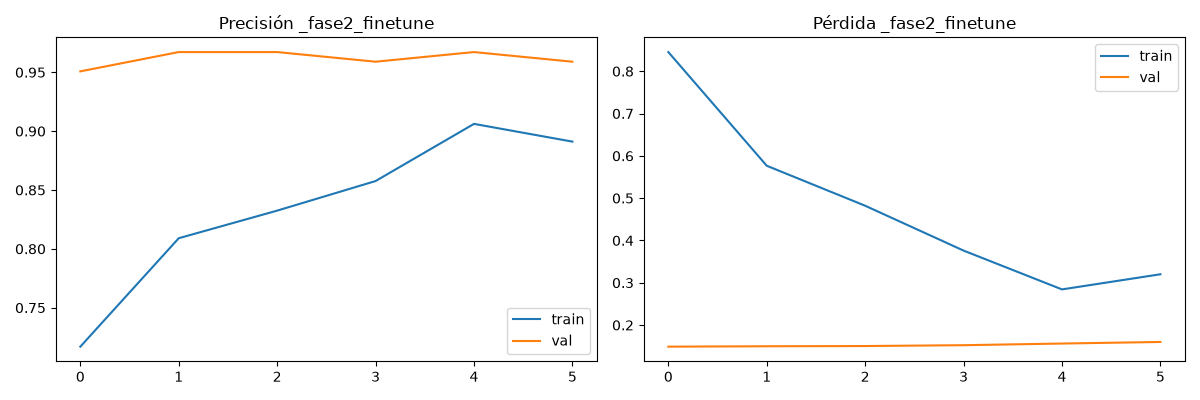

In [3]:
from IPython.display import Image, display

display(Image(filename="../models/historial_entrenamiento_fase1.png"))
display(Image(filename="../models/historial_entrenamiento_fase2_finetune.png"))

- Una vez que podamos ejecutar nuestro modelo se estara realizando una evaluacion del modelo:


    # Pasa todas las imágenes de prueba y calcula el error promedio (loss)
    # y el porcentaje de acierto global (acc)
    loss, acc = model.evaluate(test_gen)
    print(f"\nPrecisión en test: {acc:.2%}  |  Pérdida en test: {loss:.4f}")

    pred = model.predict(test_gen)          # Probabilidades softmax para cada imagen
    y_pred = np.argmax(pred, axis=1)        # Clase con mayor probabilidad predicha
    y_true = test_gen.classes               # Etiquetas verdaderas
    nombres_clases = list(test_gen.class_indices.keys())  # Nombres de las especies

    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred, target_names=nombres_clases))

    print("Matriz de confusión:")
    print(confusion_matrix(y_true, y_pred))

| Clase                 | Precision | Recall | F1-Score | Support |
|-----------------------|----------:|--------:|---------:|--------:|
| Atun_aleta_amarilla   | 1.00 | 0.80 | 0.89 | 5 |
| Camaron               | 1.00 | 1.00 | 1.00 | 8 |
| Corvina               | 0.80 | 1.00 | 0.89 | 8 |
| Corvina_reina         | 0.83 | 1.00 | 0.91 | 5 |
| Dorada                | 1.00 | 0.80 | 0.89 | 5 |
| Espadín_del_mar_negro | 1.00 | 1.00 | 1.00 | 8 |
| Jurel                 | 1.00 | 0.88 | 0.93 | 8 |
| Marlin_pez_vela       | 1.00 | 0.80 | 0.89 | 5 |
| Parg_rojo             | 0.89 | 1.00 | 0.94 | 8 |
| Pargo_mancha          | 0.96 | 0.90 | 0.93 | 29 |
| Pez_dorado            | 1.00 | 0.67 | 0.80 | 6 |
| Salmonete             | 1.00 | 1.00 | 1.00 | 8 |
| Salmonete_de_fango    | 1.00 | 1.00 | 1.00 | 8 |
| Tiburon_martillo      | 1.00 | 1.00 | 1.00 | 6 |
| Tortuga               | 0.80 | 1.00 | 0.89 | 16 |
| Trucha                | 1.00 | 1.00 | 1.00 | 5 |
| **Accuracy**          | - | - | **0.93** | **138** |
| **Macro Avg**         | **0.96** | **0.93** | **0.93** | **138** |
| **Weighted Avg**      | **0.94** | **0.93** | **0.93** | **138** |

Al finalizar la ejecucion del modelo se obtiene la precision del 93%, se procede a generar el archivo .keras para ser analizado en streamlit
